In [1]:
# ==========================================
# LEVEL 3: LOAD DATASET
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/clean_dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset loaded successfully!
Rows: 34500
Columns: 22

Column Names:
['order_id', 'customer_id', 'product_id', 'category', 'price', 'discount', 'quantity', 'payment_method', 'order_date', 'delivery_time_days', 'region', 'returned', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender', 'order_year', 'order_month', 'order_month_name', 'profit_amount', 'calculated_profit_margin']

Data Types:
order_id                     object
customer_id                  object
product_id                   object
category                     object
price                       float64
discount                    float64
quantity                      int64
payment_method               object
order_date                   object
delivery_time_days            int64
region                       object
returned                     object
total_amount                float64
shipping_cost               float64
profit_margin               float64
customer_age                  int64
c

In [2]:
# ==========================================
# LEVEL 4: DESCRIPTIVE STATISTICS
# ==========================================

numeric_columns = [
    "price",
    "discount",
    "quantity",
    "delivery_time_days",
    "total_amount",
    "shipping_cost",
    "profit_margin",
    "customer_age",
    "profit_amount",
    "calculated_profit_margin"
]

# Calculate descriptive statistics
descriptive_stats = df[numeric_columns].describe().T

# Add median separately
descriptive_stats["median"] = df[numeric_columns].median()

# Reorder columns
descriptive_stats = descriptive_stats[
    [
        "count",
        "mean",
        "median",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

# Rename for readability
descriptive_stats.columns = [
    "Count",
    "Mean",
    "Median",
    "Std_Deviation",
    "Minimum",
    "Q1",
    "Q2_Median",
    "Q3",
    "Maximum"
]

print("========== DESCRIPTIVE STATISTICS ==========")

display(descriptive_stats.round(2))

========== DESCRIPTIVE STATISTICS ==========


,Count,Mean,Median,Std_Deviation,Minimum,Q1,Q2_Median,Q3,Maximum
price,34500.0,90.12,45.66,97.86,1.01,16.69,45.66,130.95,302.34
discount,34500.0,0.05,0.00,0.07,0.00,0.00,0.00,0.10,0.30
quantity,34500.0,1.49,1.00,0.93,1.00,1.00,1.00,2.00,5.00
delivery_time_days,34500.0,4.81,5.00,1.24,3.00,4.00,5.00,6.00,13.00
total_amount,34500.0,115.60,56.82,128.30,0.82,19.71,56.82,168.53,391.76
shipping_cost,34500.0,6.15,6.09,2.39,0.00,4.42,6.09,7.83,12.94
profit_margin,34500.0,21.44,10.55,26.20,-6.20,1.50,10.55,33.13,80.58
customer_age,34500.0,43.47,43.00,14.98,18.00,31.00,43.00,56.00,69.00
profit_amount,34500.0,109.45,50.78,126.35,-2.48,15.21,50.78,160.73,385.81
calculated_profit_margin,34500.0,82.99,89.66,19.91,-288.37,78.12,89.66,95.54,100.00


## Descriptive Statistics Analysis

Descriptive statistics were calculated for the major numerical business variables, including price, discount, quantity, delivery time, sales amount, shipping cost, profit margin, customer age, and engineered profit measures.

The analysis uses the mean, median, standard deviation, minimum, maximum, and quartiles (Q1, Q2, Q3) to understand the central tendency, variability, and distribution of the business data.

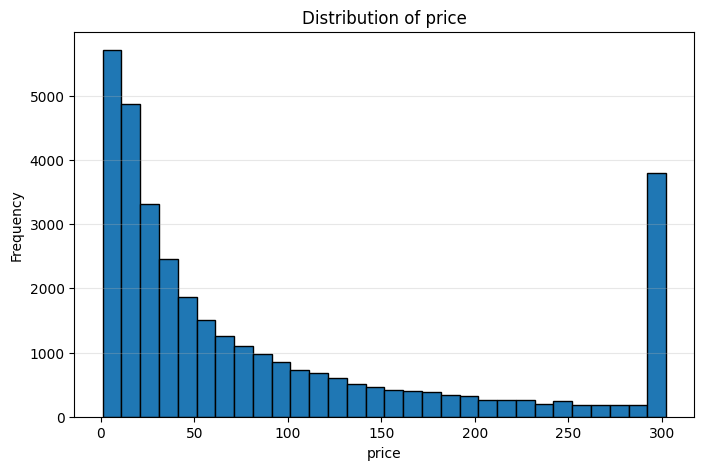

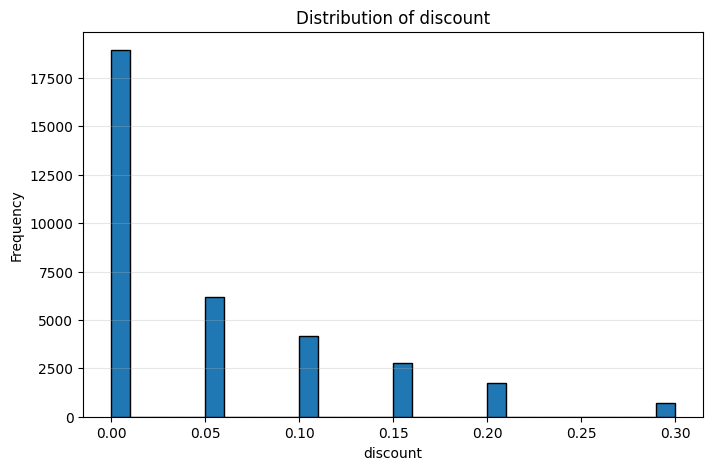

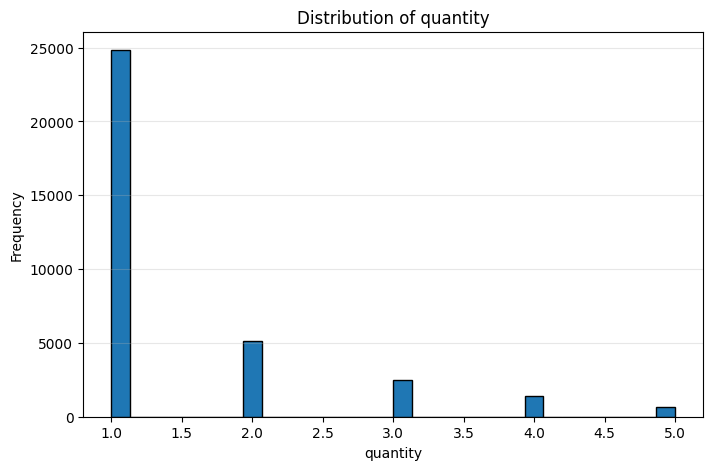

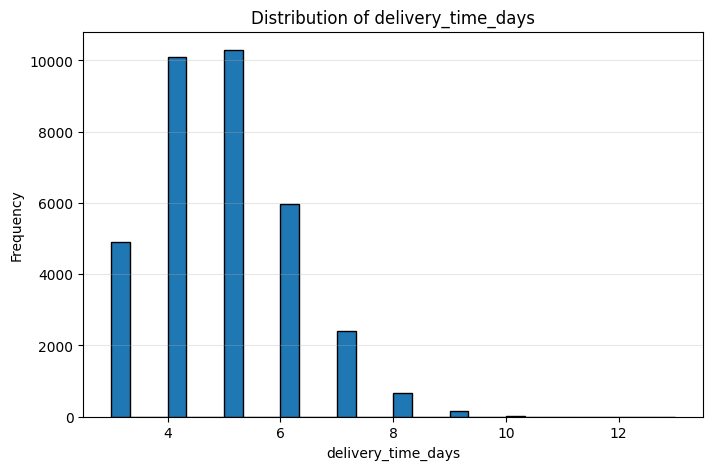

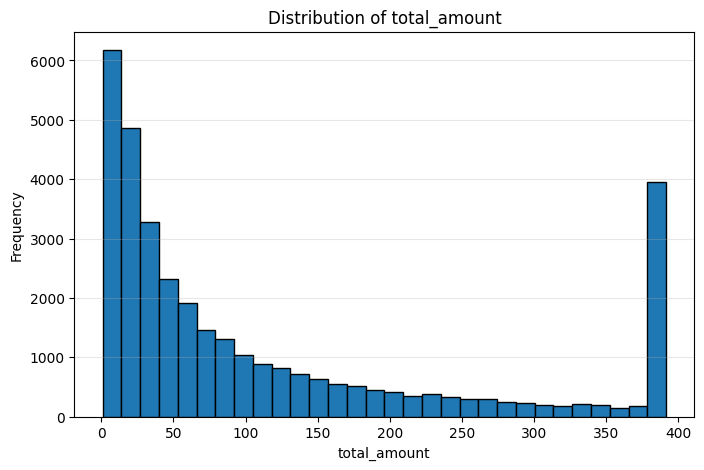

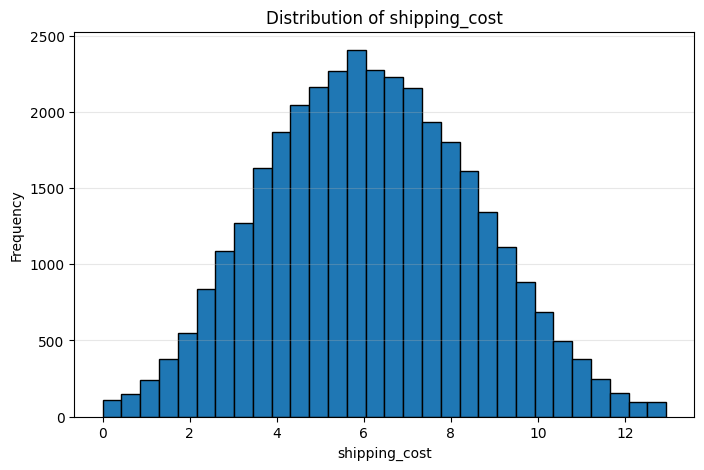

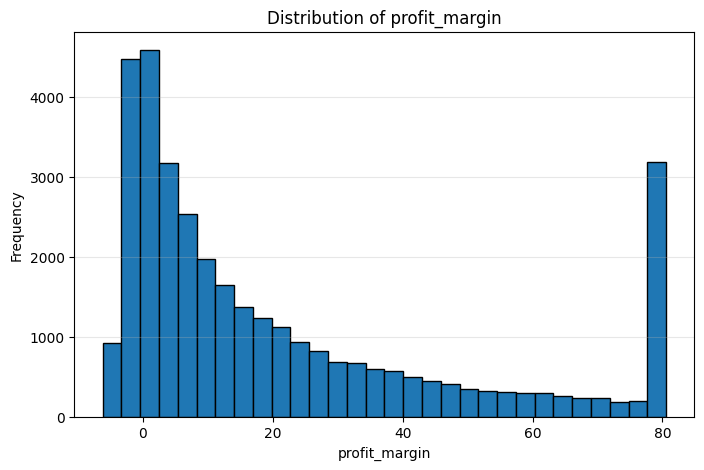

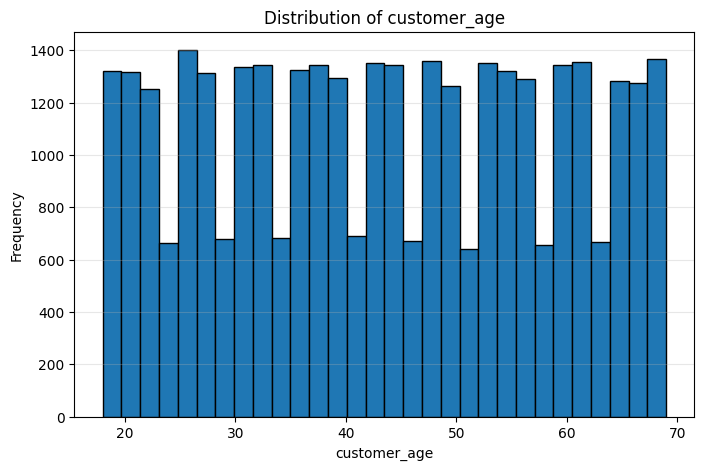

In [3]:
# ==========================================
# LEVEL 5: HISTOGRAM DISTRIBUTIONS
# ==========================================

histogram_columns = [
    "price",
    "discount",
    "quantity",
    "delivery_time_days",
    "total_amount",
    "shipping_cost",
    "profit_margin",
    "customer_age"
]

for col in histogram_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col].dropna(), bins=30, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

## Distribution Analysis

Histograms were generated to examine the distributions of the major numerical variables.

The visualizations help identify concentration, skewness, spread, and unusual observations in sales, pricing, delivery, shipping, customer, and profitability variables.

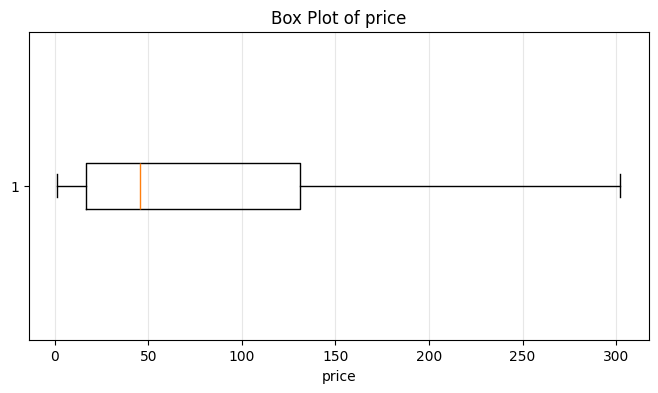

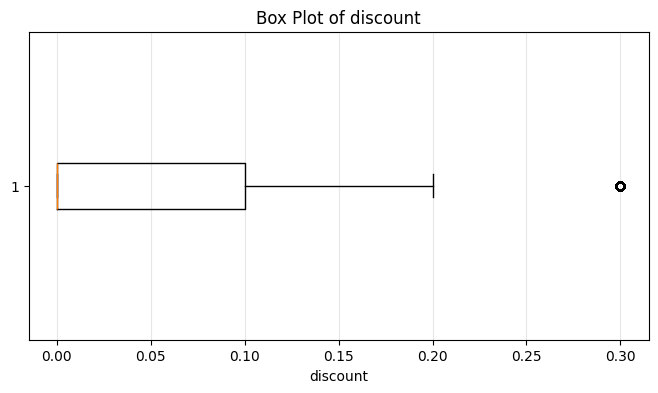

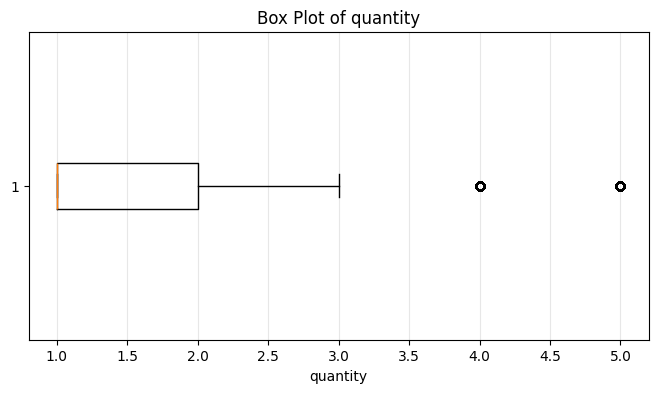

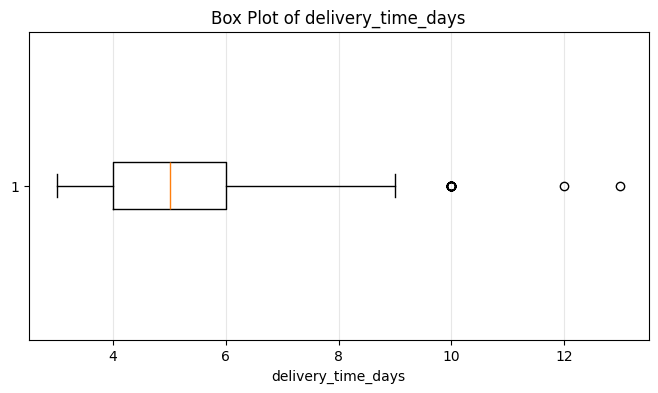

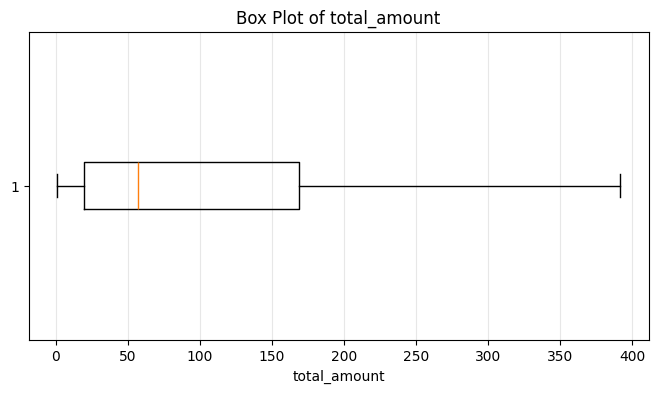

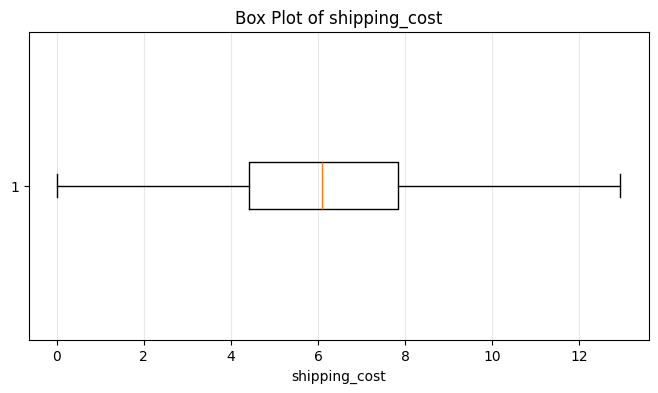

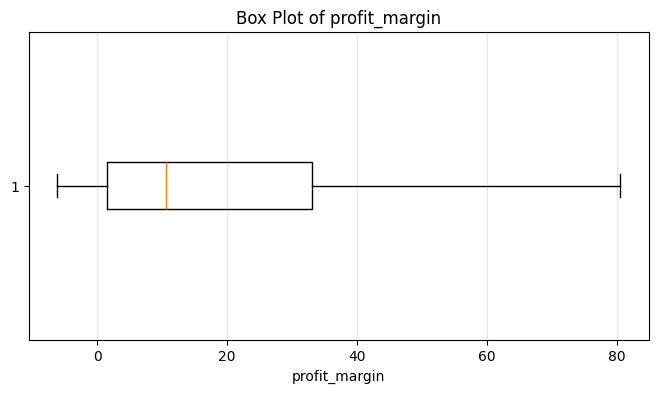

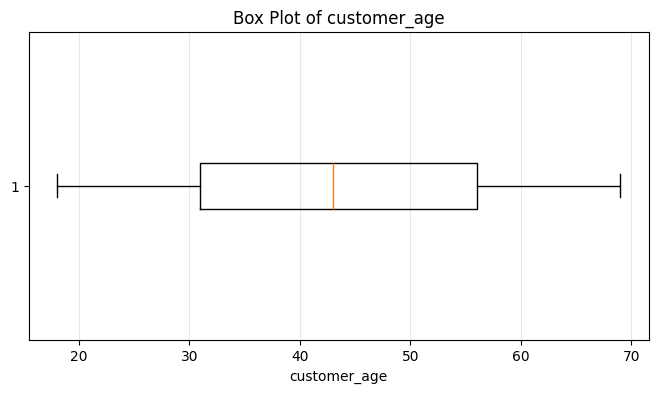

In [4]:
# ==========================================
# LEVEL 6: BOX PLOTS FOR ANOMALY DETECTION
# ==========================================

boxplot_columns = [
    "price",
    "discount",
    "quantity",
    "delivery_time_days",
    "total_amount",
    "shipping_cost",
    "profit_margin",
    "customer_age"
]

for col in boxplot_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)
    plt.grid(axis="x", alpha=0.3)
    plt.show()

## Box Plot Analysis

Box plots were used to identify potential outliers and understand the spread of the numerical variables.

The plots provide a visual representation of the median, quartiles, overall range, and observations that fall unusually far from the central distribution.

In [5]:
# ==========================================
# LEVEL 7: CORRELATION ANALYSIS
# ==========================================

correlation_columns = [
    "price",
    "discount",
    "quantity",
    "delivery_time_days",
    "total_amount",
    "shipping_cost",
    "profit_margin",
    "customer_age",
    "profit_amount",
    "calculated_profit_margin"
]

correlation_matrix = df[correlation_columns].corr()

print("========== CORRELATION MATRIX ==========")

display(correlation_matrix.round(2))

========== CORRELATION MATRIX ==========


,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age,profit_amount,calculated_profit_margin
price,1.00,0.00,0.00,0.00,0.92,0.78,0.80,-0.01,0.92,0.52
discount,0.00,1.00,-0.01,0.00,-0.04,-0.05,-0.06,0.00,-0.04,-0.05
quantity,0.00,-0.01,1.00,0.01,0.29,0.28,0.35,0.00,0.29,0.19
delivery_time_days,0.00,0.00,0.01,1.00,0.01,0.01,0.01,0.00,0.01,0.00
total_amount,0.92,-0.04,0.29,0.01,1.00,0.82,0.90,-0.01,1.00,0.53
shipping_cost,0.78,-0.05,0.28,0.01,0.82,1.00,0.77,-0.01,0.81,0.58
profit_margin,0.80,-0.06,0.35,0.01,0.90,0.77,1.00,-0.01,0.90,0.53
customer_age,-0.01,0.00,0.00,0.00,-0.01,-0.01,-0.01,1.00,-0.01,-0.01
profit_amount,0.92,-0.04,0.29,0.01,1.00,0.81,0.90,-0.01,1.00,0.53
calculated_profit_margin,0.52,-0.05,0.19,0.00,0.53,0.58,0.53,-0.01,0.53,1.00


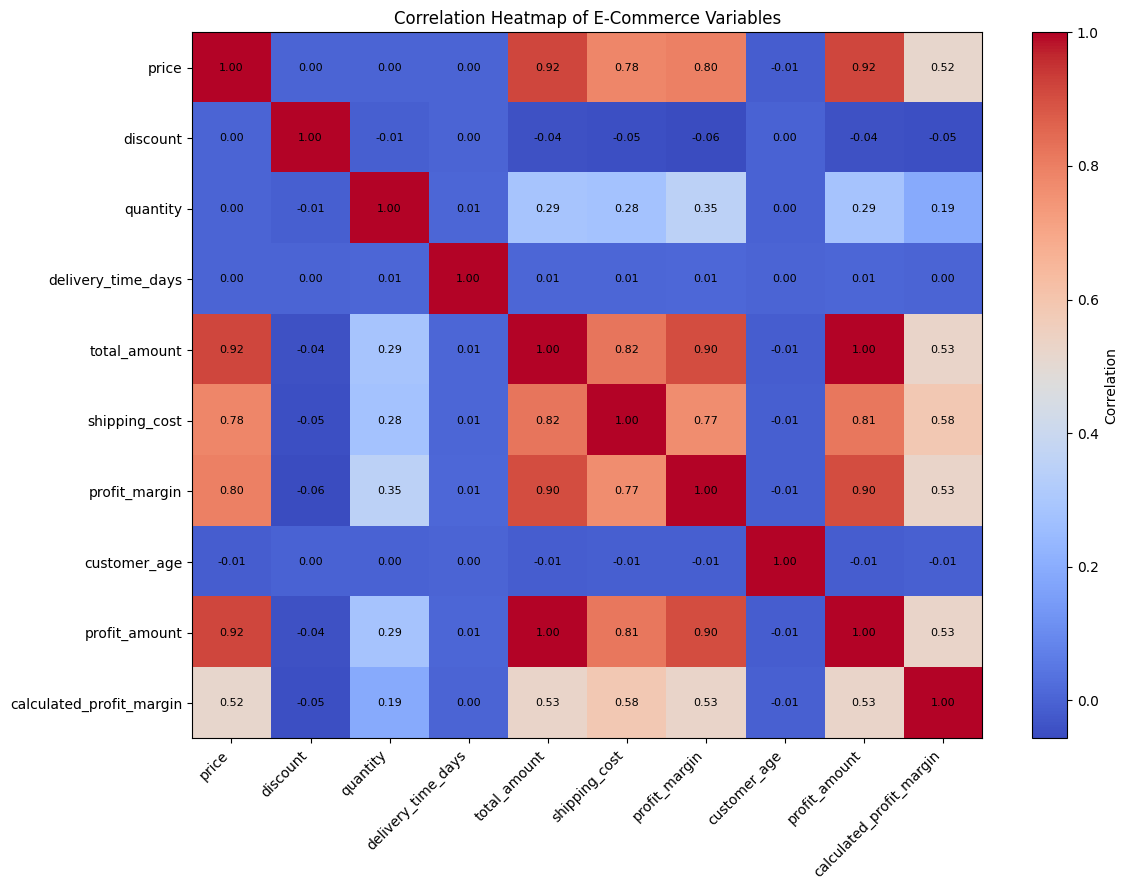

In [6]:
# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(12, 9))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap of E-Commerce Variables")

# Display correlation values
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()
plt.show()

## Correlation Analysis

A correlation matrix and heatmap were created to identify relationships between numerical business variables.

Correlation values range from -1 to +1:
- Values close to +1 indicate a strong positive relationship.
- Values close to -1 indicate a strong negative relationship.
- Values close to 0 indicate a weak or negligible linear relationship.

The correlation analysis will be used to support the business hypotheses tested later in the project.

# Business Hypothesis Testing

## Hypothesis 1: Discount vs Total Sales

**H₀ (Null Hypothesis):** Discount percentage has no significant relationship with total sales.

**H₁ (Alternative Hypothesis):** Discount percentage has a significant relationship with total sales.

---

## Hypothesis 2: Quantity vs Total Sales

**H₀ (Null Hypothesis):** Quantity has no significant relationship with total sales.

**H₁ (Alternative Hypothesis):** Quantity has a significant positive relationship with total sales.

---

## Hypothesis 3: Shipping Cost vs Profit

**H₀ (Null Hypothesis):** Shipping cost has no significant relationship with profit amount.

**H₁ (Alternative Hypothesis):** Higher shipping cost has a significant negative relationship with profit amount.

### Statistical Significance

A significance level of **α = 0.05** is used.

- **p-value < 0.05:** Reject H₀; the relationship is statistically significant.
- **p-value ≥ 0.05:** Fail to reject H₀; there is insufficient evidence of a significant relationship.

In [7]:
# ==========================================
# LEVEL 9: HYPOTHESIS TESTING
# ==========================================

from scipy.stats import pearsonr

alpha = 0.05

# ------------------------------------------
# Hypothesis 1: Discount vs Total Sales
# ------------------------------------------

r1, p1 = pearsonr(
    df["discount"],
    df["total_amount"]
)

# ------------------------------------------
# Hypothesis 2: Quantity vs Total Sales
# ------------------------------------------

r2, p2 = pearsonr(
    df["quantity"],
    df["total_amount"]
)

# ------------------------------------------
# Hypothesis 3: Shipping Cost vs Profit
# ------------------------------------------

r3, p3 = pearsonr(
    df["shipping_cost"],
    df["profit_amount"]
)

# ==========================================
# DISPLAY RESULTS
# ==========================================

results = pd.DataFrame({
    "Hypothesis": [
        "Discount vs Total Sales",
        "Quantity vs Total Sales",
        "Shipping Cost vs Profit"
    ],
    "Correlation (r)": [
        r1,
        r2,
        r3
    ],
    "P-Value": [
        p1,
        p2,
        p3
    ]
})

results["Correlation (r)"] = results["Correlation (r)"].round(4)
results["P-Value"] = results["P-Value"].round(6)

results["Decision"] = np.where(
    results["P-Value"] < alpha,
    "Reject H0",
    "Fail to Reject H0"
)

display(results)

,Hypothesis,Correlation (r),P-Value,Decision
0,Discount vs Total Sales,-0.0432,0.0,Reject H0
1,Quantity vs Total Sales,0.2859,0.0,Reject H0
2,Shipping Cost vs Profit,0.8145,0.0,Reject H0


In [8]:
# ==========================================
# LEVEL 10: HYPOTHESIS CONCLUSIONS
# ==========================================

print("========== HYPOTHESIS TESTING CONCLUSIONS ==========\n")

hypotheses = [
    ("H1: Discount vs Total Sales", r1, p1),
    ("H2: Quantity vs Total Sales", r2, p2),
    ("H3: Shipping Cost vs Profit", r3, p3)
]

for name, r, p in hypotheses:

    print(name)
    print(f"Correlation (r): {r:.4f}")
    print(f"P-value: {p:.6f}")

    if p < alpha:
        print("Decision: Reject the null hypothesis (H₀).")
        print("Result: The relationship is statistically significant.")

        if r > 0:
            print("Direction: Positive relationship.")
        elif r < 0:
            print("Direction: Negative relationship.")
        else:
            print("Direction: No meaningful linear direction.")
    else:
        print("Decision: Fail to reject the null hypothesis (H₀).")
        print("Result: There is insufficient evidence of a statistically significant relationship.")

    print("-" * 60)

========== HYPOTHESIS TESTING CONCLUSIONS ==========

H1: Discount vs Total Sales
Correlation (r): -0.0432
P-value: 0.000000
Decision: Reject the null hypothesis (H₀).
Result: The relationship is statistically significant.
Direction: Negative relationship.
------------------------------------------------------------
H2: Quantity vs Total Sales
Correlation (r): 0.2859
P-value: 0.000000
Decision: Reject the null hypothesis (H₀).
Result: The relationship is statistically significant.
Direction: Positive relationship.
------------------------------------------------------------
H3: Shipping Cost vs Profit
Correlation (r): 0.8145
P-value: 0.000000
Decision: Reject the null hypothesis (H₀).
Result: The relationship is statistically significant.
Direction: Positive relationship.
------------------------------------------------------------


## Hypothesis Testing Interpretation

The three business hypotheses were evaluated using Pearson correlation and a significance level of α = 0.05.

The statistical results determine whether the observed relationships between discount, quantity, sales, shipping cost, and profit are statistically significant.

Statistical significance indicates that the observed relationship is unlikely to have occurred purely by random sampling variation. However, correlation does not by itself establish causation.

In [9]:
# ==========================================
# LEVEL 11: KEY BUSINESS FINDINGS
# ==========================================

print("========== KEY BUSINESS METRICS ==========")

# Overall metrics
total_sales = df["total_amount"].sum()
average_order_value = df["total_amount"].mean()
total_profit = df["profit_amount"].sum()
average_profit = df["profit_amount"].mean()
average_discount = df["discount"].mean()
average_quantity = df["quantity"].mean()
average_delivery = df["delivery_time_days"].mean()

print(f"Total Sales: {total_sales:,.2f}")
print(f"Average Order Value: {average_order_value:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Average Profit per Order: {average_profit:,.2f}")
print(f"Average Discount: {average_discount:.2%}")
print(f"Average Quantity per Order: {average_quantity:.2f}")
print(f"Average Delivery Time: {average_delivery:.2f} days")

# Category performance
category_sales = (
    df.groupby("category")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

print("\n========== CATEGORY SALES ==========")
display(category_sales.to_frame("Total Sales").round(2))

# Region performance
region_sales = (
    df.groupby("region")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

print("\n========== REGION SALES ==========")
display(region_sales.to_frame("Total Sales").round(2))

# Payment method performance
payment_sales = (
    df.groupby("payment_method")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

print("\n========== PAYMENT METHOD SALES ==========")
display(payment_sales.to_frame("Total Sales").round(2))

# Monthly sales
monthly_sales = (
    df.groupby(["order_year", "order_month"])["total_amount"]
    .sum()
    .reset_index()
    .sort_values(["order_year", "order_month"])
)

print("\n========== MONTHLY SALES ==========")
display(monthly_sales.round(2))

========== KEY BUSINESS METRICS ==========
Total Sales: 3,988,178.76
Average Order Value: 115.60
Total Profit: 3,775,958.84
Average Profit per Order: 109.45
Average Discount: 4.93%
Average Quantity per Order: 1.49
Average Delivery Time: 4.81 days

========== CATEGORY SALES ==========


,Total Sales
category,
Electronics,1743266.14
Home,867136.98
Sports,556758.36
Fashion,454499.98
Beauty,152567.19
Toys,132001.28
Grocery,81948.83



========== REGION SALES ==========


,Total Sales
region,
South,883960.78
North,858887.37
East,810697.23
West,796903.36
Central,637730.02



========== PAYMENT METHOD SALES ==========


,Total Sales
payment_method,
Credit Card,1404849.83
Debit Card,984576.02
UPI,481827.57
COD,478483.88
PayPal,399419.95
Wallet,239021.51



========== MONTHLY SALES ==========


,order_year,order_month,total_amount
0,2023,9,103640.80
1,2023,10,166092.25
2,2023,11,158670.44
3,2023,12,170600.09
4,2024,1,162052.04
5,2024,2,153520.04
6,2024,3,164791.31
7,2024,4,170812.79
8,2024,5,173615.23
9,2024,6,154990.65


# Top 5 Critical Business Findings

Based on the exploratory analysis, descriptive statistics, correlation analysis, and hypothesis testing, the following five findings represent the most important business insights from the e-commerce dataset:

1. **Sales Performance:** Overall sales and average order value provide a baseline for evaluating business performance.

2. **Category Performance:** Differences in total sales across product categories indicate which categories contribute most strongly to revenue.

3. **Regional Performance:** Regional sales variation highlights geographic markets with stronger or weaker revenue contribution.

4. **Customer Order Behavior:** The relationship between quantity and total sales helps assess whether larger orders are associated with higher revenue.

5. **Profitability and Costs:** The relationship between shipping costs, profit, and profit margins provides insight into the impact of fulfillment costs on profitability.

These findings can support decisions related to product strategy, regional expansion, pricing, promotions, inventory planning, and logistics optimization.

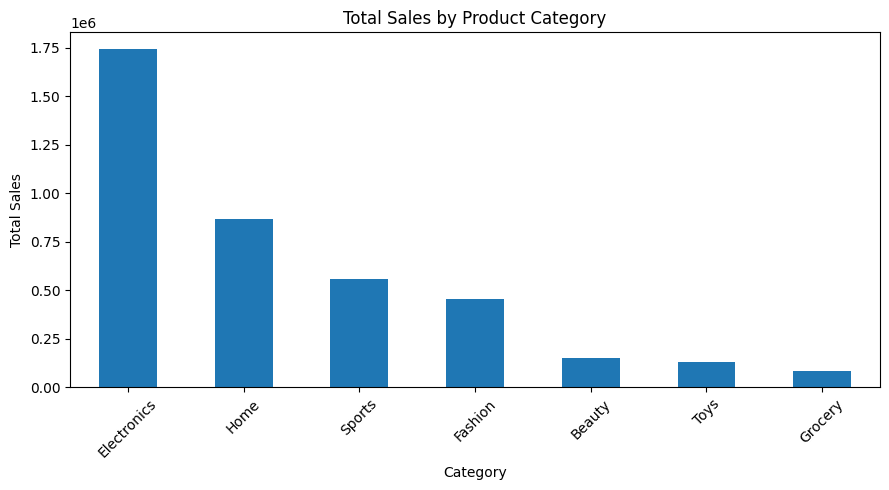

In [10]:
# ==========================================
# LEVEL 12: BUSINESS VISUALIZATIONS
# ==========================================

# 1. Total Sales by Category

category_sales = (
    df.groupby("category")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
category_sales.plot(kind="bar")
plt.title("Total Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

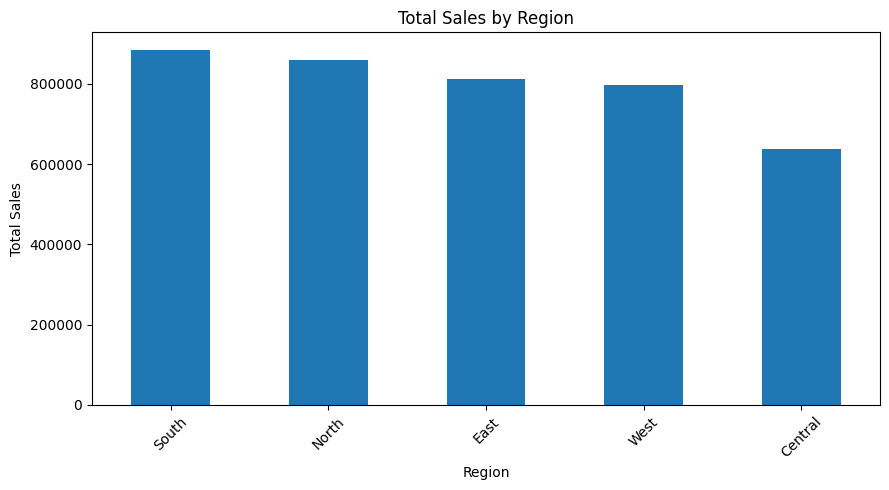

In [11]:
# 2. Total Sales by Region

region_sales = (
    df.groupby("region")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
region_sales.plot(kind="bar")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

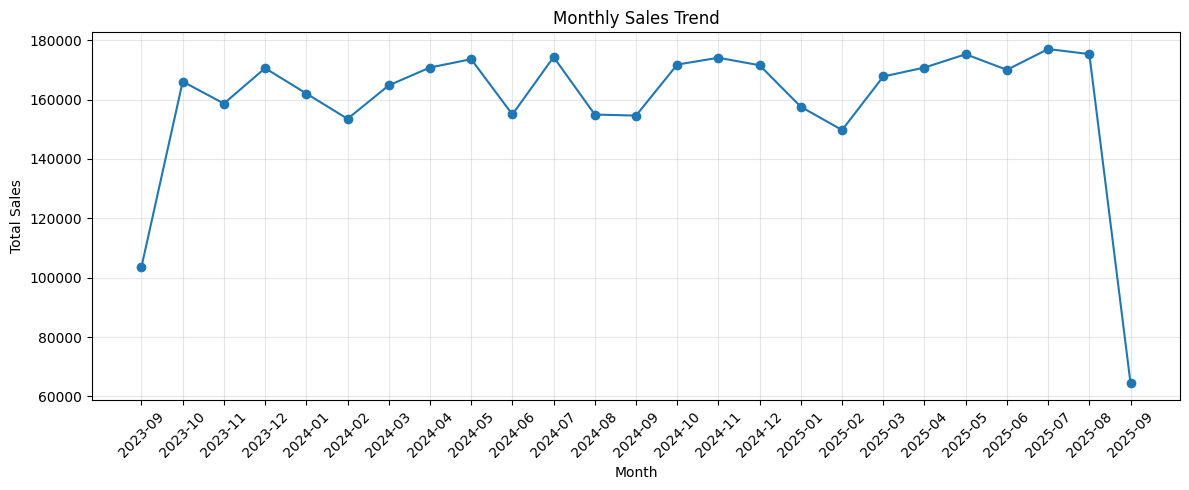

In [12]:
# 3. Monthly Sales Trend

monthly_sales = (
    df.groupby(["order_year", "order_month"])["total_amount"]
    .sum()
    .reset_index()
)

monthly_sales["period"] = (
    monthly_sales["order_year"].astype(str)
    + "-"
    + monthly_sales["order_month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12, 5))
plt.plot(
    monthly_sales["period"],
    monthly_sales["total_amount"],
    marker="o"
)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

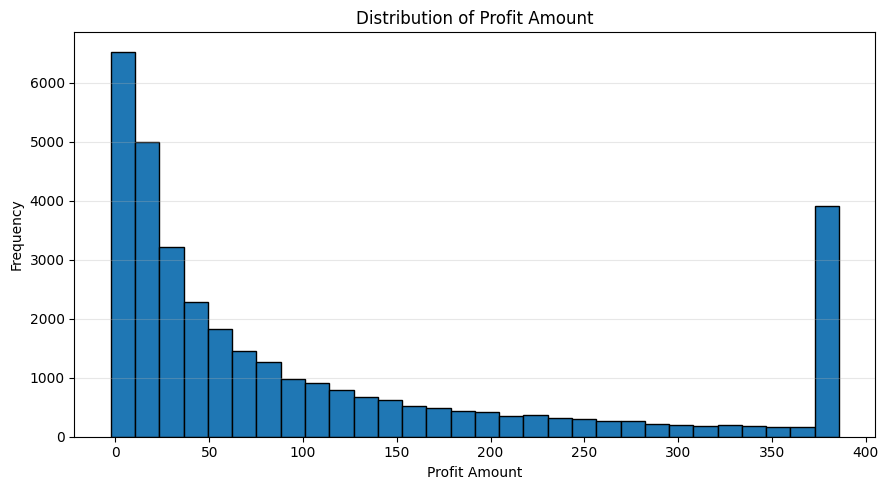

In [13]:
# 4. Profit Amount Distribution

plt.figure(figsize=(9, 5))
plt.hist(df["profit_amount"], bins=30, edgecolor="black")
plt.title("Distribution of Profit Amount")
plt.xlabel("Profit Amount")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Business Visualization Summary

The visual analysis provides a clear view of category performance, regional sales contribution, monthly sales trends, and the distribution of profit.

These visualizations complement the descriptive statistics and hypothesis tests by presenting important business patterns in an easy-to-interpret format.

# Executive Summary

## Project Overview

This project analyzed a cleaned e-commerce transaction dataset containing 34,500 records and 22 variables. Exploratory data analysis and statistical techniques were used to understand sales performance, customer ordering behavior, profitability, and operational factors.

## Key Analysis Performed

- Calculated descriptive statistics including mean, median, standard deviation, and quartiles.
- Examined numerical distributions using histograms.
- Identified potential outliers using box plots.
- Analyzed relationships between numerical variables using a correlation matrix and heatmap.
- Formulated and statistically tested three business hypotheses.
- Analyzed sales performance across product categories and regions.
- Examined monthly sales trends.
- Analyzed profit distribution and operational costs.

## Business Implications

The analysis provides useful evidence for understanding revenue drivers, customer purchasing behavior, regional performance, and profitability. The results can support data-driven decisions involving pricing, promotions, product categories, regional strategy, inventory planning, and logistics.

## Final Conclusion

Exploratory and statistical analysis transformed the cleaned transaction data into actionable business insights. Combining descriptive statistics, visual analysis, correlation analysis, and hypothesis testing provides a stronger foundation for evidence-based business decision-making.

**Note:** Statistical correlation identifies associations between variables but does not establish causation. Business decisions should therefore consider additional operational and contextual information.

In [14]:
# ==========================================
# FINAL PROJECT VERIFICATION
# ==========================================

print("========== FINAL PROJECT CHECK ==========")
print("Dataset rows:", df.shape[0])
print("Dataset columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nTask 4 analysis completed:")
print("✓ Descriptive statistics")
print("✓ Histograms")
print("✓ Box plots")
print("✓ Correlation matrix")
print("✓ Correlation heatmap")
print("✓ 3 business hypotheses")
print("✓ Statistical hypothesis testing")
print("✓ Top 5 business findings")
print("✓ Business visualizations")
print("✓ Executive summary")

print("\nTASK 4 COMPLETED SUCCESSFULLY!")

========== FINAL PROJECT CHECK ==========
Dataset rows: 34500
Dataset columns: 22
Missing values: 0
Duplicate rows: 0

Task 4 analysis completed:
✓ Descriptive statistics
✓ Histograms
✓ Box plots
✓ Correlation matrix
✓ Correlation heatmap
✓ 3 business hypotheses
✓ Statistical hypothesis testing
✓ Top 5 business findings
✓ Business visualizations
✓ Executive summary

TASK 4 COMPLETED SUCCESSFULLY!
